# WP4 Annex A, Level 2: basalt objects, checked basis piece by basis piece

Level 2 of the sediment-hosted recipe generates the basalt piles that are the concept's anomaly source and copper donor: a marked point process on the basement surface, with lateral extents, stacked-flow thicknesses and an elongation drawn from distributions, and an intensity raised along O'Driscoll's lineaments. Annex A closes the level with *"Basis: Roopena mapping, the WMC targeting memoranda, O'Driscoll's interpretation."* Three pieces, taken one at a time:

- **Part A: Roopena mapping.** The one place the basalt object could be seen before t0 is the Roopena volcanic field on the southeastern Stuart Shelf, about 257 km from the deposit. Sources: the 1952 Roopena 1-mile map, the 1968 PORT AUGUSTA 1:250,000 sheet, Risely's 1968 gravity and magnetic survey (RB 67/00081), BHP's 1970 SML 204 summary, and the pre-t0 drill logs.
- **Part B: the WMC targeting memoranda.** Not in any public archive; the part shows what stands in for them.
- **Part C: O'Driscoll's interpretation.** The GA scans of WMC's original lineament and target sheets (eCat 79287), 34 of them on the window, dated here from their faces.

Each part ends with a verdict on the piece. Part D lays the Annex A Level 2 parameter rows against what the pieces can now cite. Only files in `wp4_prior_state/annexA_levels/level2_basalt_objects/` are read. The information-state rule is one cutoff, t0 = 2 May 1975 (the EL 190 grant). Figures are drawn at final printed width and saved at 300 dpi to `03_results/wp4_prior/figures/` as `wp4_L2_<part><step>_*.png`. One rule from Annex A section 2 governs the whole level: the basalt-object frequency must come from geology, never from counting the anomalies on the t0 gravity and magnetic maps, because those maps weight the prior later; nothing below counts anomalies.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

All reads are relative paths into the Level 2 folder. The cell summarises each piece's subfolder and loads the tables. The transcriptions (Risely's specific gravities and hole logs, the O'Driscoll sheet dates, the 1974 target circles) were made on 2026-09-21 and carry their page or pixel provenance in their own columns. The deposit's position in AGD66 / AMG zone 53, the datum of O'Driscoll's world files, is hard-coded from a pyproj conversion so the notebook needs no projection library.


In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
Image.MAX_IMAGE_PIXELS = None

L2 = Path("../../01_data/wp1_data/database/wp4_prior_state/annexA_levels/level2_basalt_objects")
FIG = Path("../../03_results/wp4_prior/figures")
assert L2.is_dir(), "run from 02_code/notebooks/"
FIG.mkdir(parents=True, exist_ok=True)
RM, ODI, WM = L2 / "roopena_mapping", L2 / "odriscoll_interpretation", L2 / "wmc_targeting_memoranda"

T0 = pd.Timestamp("1975-05-02")                        # EL 190 grant: the one cutoff
OD_LON, OD_LAT = 136.887, -30.441                      # Olympic Dam (wp1_harvester OD_CENTER, GDA2020)
OD_E66, OD_N66 = 681074.3, 6630662.0                   # same point, AGD66 / AMG53 (pyproj EPSG:28353 -> 20253)
FT = 0.3048
PIECE_COL = {1: "#2a78d6", 2: "#eda100", 3: "#3b9c5a"} # one colour per basis piece, used in every figure

def haversine_km(lon1, lat1, lon2, lat2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

for sub in sorted(p for p in L2.iterdir() if p.is_dir()):
    files = [p for p in sub.rglob("*") if p.is_file()]
    print(f"{sub.name:26s} {len(files):4d} files {sum(p.stat().st_size for p in files)/1e6:7.1f} MB")
    for p in sorted(sub.iterdir()):
        n = len(list(p.rglob("*"))) if p.is_dir() else None
        print(f"      {p.name}" + (f"/  ({n} files)" if n is not None else ""))

holes = pd.read_csv(RM / "roopena_beda_drillholes_pre_t0_intervals.csv")
sg = pd.read_csv(RM / "transcriptions/risely1968_specific_gravity.csv")
rlog = pd.read_csv(RM / "transcriptions/risely1968_sadm_hole_logs.csv")
rtext = (RM / "transcriptions/risely1968_text.txt").read_text(encoding="utf-8").splitlines()
dates = pd.read_csv(ODI / "odriscoll_window_sheet_dates.csv")
tgt = pd.read_csv(ODI / "odriscoll_OD6iv_1974_blue_targets.csv")
print(f"\npre-t0 holes logging Roopena/Beda/Backy Point units: {holes.DH_NAME.nunique()}; Risely SG samples: {len(sg)}; "
      f"O'Driscoll window sheets dated: {len(dates)}; 1974 blue target circles: {len(tgt)}")


odriscoll_interpretation    144 files   169.8 MB
      O'Driscoll Index.xlsx
      O'Driscoll Lineament Maps metadata.docx
      odriscoll_maps_manifest.csv
      odriscoll_OD6iv_1974_blue_targets.csv
      odriscoll_sa_sheets_index.csv
      odriscoll_window_sheet_dates.csv
      page_crops/  (2 files)
      window_sheets/  (136 files)
roopena_mapping              12 files    56.7 MB
      annexA_sources_manifest.csv
      ENV01174.pdf
      Port Augusta 250K Sheet SI 53-04 Geological map(rev 1).PDF
      RB6700081.pdf
      renders/  (2 files)
      Roopena 1 Mile geological map (Port Augusta 250k).PDF
      roopena_beda_drillholes_pre_t0_intervals.csv
      transcriptions/  (4 files)
wmc_targeting_memoranda       9 files    15.4 MB
      finding_aid_not_admissible/  (1 files)
      nearest_admissible_EL190_Q1/  (7 files)
      NOT_FOUND.md

pre-t0 holes logging Roopena/Beda/Backy Point units: 20; Risely SG samples: 26; O'Driscoll window sheets dated: 34; 1974 blue target circles: 20

## Step 0. Before the pieces: what Level 2 holds and when it dates from

Each source is placed at the date on its own face against t0, coloured by the basis piece it serves. Two cases need a second mark. BHP's 1970 Roopena summary was written before t0, but its envelope was released to open file on 8 November 1977; under a ruling that the prior represents an idealised explorer with all open-file data, it would be out. The EL 190 first quarterly is the nearest admissible WMC statement for piece 2 and was written a quarter after t0. O'Driscoll's sheets are drawn only where they carry pre-t0 content: dated before t0 (in state) or with 1974 content under later additions (partly).


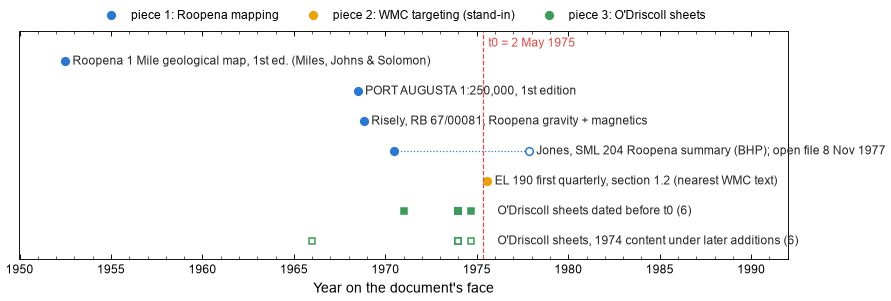

status_t0
out        15
undated     7
in          6
partly      6
sheets dated before t0: OD4_iv, OD4_ix, OD4_xxxii, OD5_iii, OD7_i, OD7_v


In [6]:
docs = [   # label, date, piece
    ("Roopena 1 Mile geological map, 1st ed. (Miles, Johns & Solomon)", "1952-07-01", 1),
    ("PORT AUGUSTA 1:250,000, 1st edition", "1968-07-01", 1),
    ("Risely, RB 67/00081, Roopena gravity + magnetics", "1968-11-01", 1),
    ("Jones, SML 204 Roopena summary (BHP)", "1970-07-01", 1),
    ("EL 190 first quarterly, section 1.2 (nearest WMC text)", "1975-08-02", 2),
]
docs = pd.DataFrame(docs, columns=["label", "date", "piece"]); docs["date"] = pd.to_datetime(docs.date)
dec = lambda ts: ts.year + (ts.dayofyear - 1) / 365.25
docs["year"] = docs.date.map(dec); T0Y = dec(T0)
dates["year_first"] = dates.date_on_face.astype(str).str.extract(r"(19\d\d)")[0].astype(float)
dates.loc[dates.date_on_face.astype(str).str.startswith("Sept"), "year_first"] += 0.67

fig, ax = plt.subplots(figsize=(COL2, 3.0))
fig.subplots_adjust(left=0.02, right=0.99, top=0.83, bottom=0.14)
rows = list(docs.label) + ["O'Driscoll sheets dated before t0", "O'Driscoll sheets, 1974 content under later additions"]
OPEN = dec(pd.Timestamp("1977-11-08"))
for i, r in docs.iterrows():
    ax.plot(r.year, i, "o", color=PIECE_COL[r.piece], ms=5)
    lab_x = OPEN + 0.4 if i == 3 else r.year + 0.4
    ax.text(lab_x, i, r.label + ("; open file 8 Nov 1977" if i == 3 else ""), va="center", color="0.15")
ax.plot([dec(pd.Timestamp("1970-07-01")), OPEN], [3, 3], color=PIECE_COL[1], lw=0.8, ls=":")
ax.plot(OPEN, 3, "o", mfc="white", mec=PIECE_COL[1], ms=5)
for k, st in enumerate(["in", "partly"]):
    y = len(docs) + k; sub = dates[dates.status_t0 == st]
    ax.plot(sub.year_first, np.full(len(sub), y), "s", color=PIECE_COL[3], ms=4, mfc=PIECE_COL[3] if st == "in" else "white")
    ax.text(T0Y + 0.8, y, rows[len(docs) + k] + f" ({len(sub)})", va="center", color="0.15")
ax.axvline(T0Y, color="#e34948", lw=0.8, ls="--")
ax.text(T0Y + 0.3, -0.6, "t0 = 2 May 1975", color="#e34948", va="center")
ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(rows) - 0.4, -1.0)
ax.set_xlim(1950, 1992); ax.set_xlabel("Year on the document's face")
h = [plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[k], ms=5, label=l) for k, l in
     [(1, "piece 1: Roopena mapping"), (2, "piece 2: WMC targeting (stand-in)"), (3, "piece 3: O'Driscoll sheets")]]
ax.legend(handles=h, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
fig.savefig(FIG / "wp4_L2_00_information_state.png", dpi=300)
plt.show()
print(dates.status_t0.value_counts().to_string())
print("sheets dated before t0:", ", ".join(dates.loc[dates.status_t0 == "in", "sheet"]))


### How to read this figure

Each row is one Level 2 source placed at the year printed on it; the red dashed line is t0. Blue marks serve piece 1 (Roopena), orange piece 2 (the stand-in for the WMC memoranda), green piece 3 (O'Driscoll). The dotted line on the Jones row runs from the report's writing date (July 1970) to its open-file date (8 November 1977, open circle). The two green rows are O'Driscoll's window sheets: solid squares are the 6 sheets dated before t0 (OD4 ix 1971; OD4 iv, OD4 xxxii, OD5 iii and OD7 v 1974; OD7 i Sept 1974), open squares the 6 whose 1974 content sits under later additions. The other 22 window sheets are dated after t0 (15) or carry no date (7) and are not drawn. What the reader should see is that all of piece 1 predates t0, that piece 2 has no written source before t0 at all, and that O'Driscoll's in-state work clusters in 1974, the year before the grant.


## Part A, basis piece 1: Roopena mapping

### Step A1. The Roopena volcanics on the 1952 and the 1968 map

The annex expects the Roopena mapping to give the outcrop dimensions of the one basalt object observable before t0. The 1952 Roopena 1-mile sheet is the mapping it names, so it comes first: panel (a) is a 16 by 12 km crop around Roopena homestead at the sheet's own 1 inch to 1 mile scale. Panel (b) is the same ground on the 1968 PORT AUGUSTA sheet, placed by its neat lines (136.5 to 138 E, 32 to 33 S), with the unit the 1968 legend names ROOPENA VOLCANICS (symbol Pcr, bright green) outlined by its colour, and the pre-t0 collars of the Roopena diamond holes and the BHP percussion holes. The cell measures every Pcr patch on the 1968 sheet.


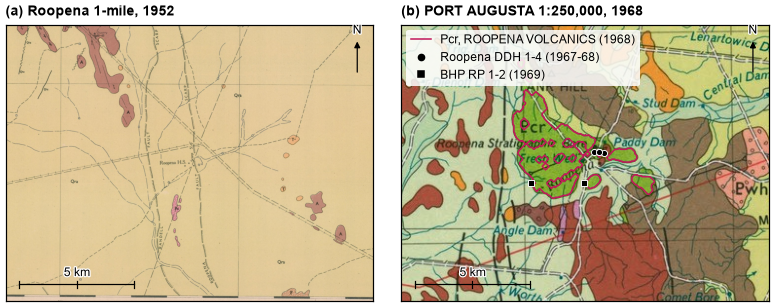

 label  area_km2  ew_km  ns_km  long_axis_km  short_axis_km  azimuth_deg    lon    lat                            field
     5      7.53   3.56   4.66          4.62           2.85       157.14 137.37 -32.72                          Roopena
     6      0.56   1.27   0.55          1.29           0.59        90.24 137.41 -32.72                          Roopena
    11      0.48   0.93   0.80          1.07           0.64       121.10 137.42 -32.73                          Roopena
     2      0.34   0.55   0.89          0.87           0.54         7.81 137.94 -32.24 Depot Creek (Flinders foothills)
     1      0.31   0.59   1.23          1.38           0.50       171.10 137.94 -32.22 Depot Creek (Flinders foothills)

Roopena field: 3 patches, 8.6 km2 in all; main patch 7.5 km2, 4.7 km N-S by 3.6 km E-W, long axis at azimuth 157 deg


In [7]:
# 1952 Roopena 1-mile render: 150 dpi, 1 inch = 1 mile, so 150 px per mile; Roopena H.S. read by eye on the render
RO = Image.open(RM / "renders/roopena_1mile_1952_150dpi.jpg").convert("RGB")
PXKM52 = 150 / 1.609344
HS52 = (3650, 2314)
# 1968 PORT AUGUSTA render: neat lines read from the graticule corners (checked on the four corner crops)
PA = np.asarray(Image.open(RM / "renders/port_augusta_1968_first_edition_150dpi.jpg").convert("RGB"))
PA_L, PA_R, PA_T, PA_B = 672, 3998, 379, 2998
ppdx, ppdy = (PA_R - PA_L) / 1.5, (PA_B - PA_T) / 1.0
kmx, kmy = 111.32 * np.cos(np.radians(32.5)) / ppdx, 110.9 / ppdy
def pa_px(lon, lat):
    return PA_L + (lon - 136.5) * ppdx, PA_T + (-32.0 - lat) * ppdy

def pcr_mask(arr):   # 1968 legend unit Pcr (ROOPENA VOLCANICS): saturated yellow-green
    r, g, b = (arr[..., i].astype(int) for i in range(3))
    m = (g > 115) & (g < 190) & (b < 90) & (g - b > 75) & (g - r > 20) & (g - r < 75)
    return ndimage.binary_closing(ndimage.binary_opening(m, iterations=2), iterations=3)
mask = np.zeros(PA.shape[:2], bool)
mask[PA_T:PA_B, PA_L:PA_R] = pcr_mask(PA[PA_T:PA_B, PA_L:PA_R])
lab, n = ndimage.label(mask)
rows = []
for i in range(1, n + 1):
    ys, xs = np.where(lab == i); area = len(xs) * kmx * kmy
    if area < 0.3: continue
    X, Y = (xs - xs.mean()) * kmx, -(ys - ys.mean()) * kmy
    ev, evec = np.linalg.eigh(np.cov(np.vstack([X, Y]))); v = evec[:, 1]
    rows.append(dict(label=i, area_km2=area, ew_km=np.ptp(X), ns_km=np.ptp(Y), long_axis_km=4 * np.sqrt(ev[1]),
                     short_axis_km=4 * np.sqrt(ev[0]), azimuth_deg=np.degrees(np.arctan2(v[0], v[1])) % 180,
                     lon=136.5 + (xs.mean() - PA_L) / ppdx, lat=-32.0 - (ys.mean() - PA_T) / ppdy))
pcr = pd.DataFrame(rows).sort_values("area_km2", ascending=False).reset_index(drop=True)
pcr["field"] = np.where(pcr.lon < 137.6, "Roopena", "Depot Creek (Flinders foothills)")

col = holes.drop_duplicates("DH_NAME")[["DH_NAME", "lon_dd", "lat_dd", "drill_date"]]
col = col[col.DH_NAME.str.contains("ROOPENA|BHP RP")]
c_lon, c_lat = col.lon_dd.mean(), col.lat_dd.mean()
HW, HH = 8.0, 6.0

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(COL2, 2.85))
fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.02, wspace=0.04)
x0, y0 = HS52
ax0.imshow(np.asarray(RO.crop((int(x0 - HW * PXKM52), int(y0 - HH * PXKM52), int(x0 + HW * PXKM52), int(y0 + HH * PXKM52)))),
           extent=(-HW, HW, -HH, HH), interpolation="antialiased")
cx, cy = pa_px(c_lon, c_lat)
crop = PA[int(cy - HH / kmy):int(cy + HH / kmy), int(cx - HW / kmx):int(cx + HW / kmx)]
mcrop = mask[int(cy - HH / kmy):int(cy + HH / kmy), int(cx - HW / kmx):int(cx + HW / kmx)]
ax1.imshow(crop, extent=(-HW, HW, -HH, HH), interpolation="antialiased")
ax1.contour(np.linspace(-HW, HW, mcrop.shape[1]), np.linspace(HH, -HH, mcrop.shape[0]), mcrop.astype(float), levels=[0.5],
            colors="#c2185b", linewidths=1.0)
for _, r in col.iterrows():
    ex, ey = (r.lon_dd - c_lon) * 111.32 * np.cos(np.radians(r.lat_dd)), (r.lat_dd - c_lat) * 110.9
    ax1.plot(ex, ey, "o" if "ROOPENA" in r.DH_NAME else "s", color="black", mec="white", mew=0.6, ms=4)
for ax in (ax0, ax1):
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
    for s_ in ax.spines.values(): s_.set_linewidth(0.8)
    for k in (0, 2.5, 5):
        ax.plot([-HW + 0.6 + k] * 2, [-HH + 0.55, -HH + 0.85], color="black", lw=0.8)
    ax.plot([-HW + 0.6, -HW + 5.6], [-HH + 0.7, -HH + 0.7], color="black", lw=0.8)
    ax.text(-HW + 3.1, -HH + 0.95, "5 km", ha="center", va="bottom", path_effects=HALO)
    ax.annotate("", xy=(HW - 0.7, HH - 0.6), xytext=(HW - 0.7, HH - 2.2), arrowprops=dict(arrowstyle="-|>", color="black", lw=0.8))
    ax.text(HW - 0.7, HH - 0.5, "N", ha="center", va="bottom", path_effects=HALO)
h = [plt.Line2D([], [], color="#c2185b", lw=1.0, label="Pcr, ROOPENA VOLCANICS (1968)"),
     plt.Line2D([], [], marker="o", ls="", color="black", ms=4, label="Roopena DDH 1-4 (1967-68)"),
     plt.Line2D([], [], marker="s", ls="", color="black", ms=4, label="BHP RP 1-2 (1969)")]
ax1.legend(handles=h, loc="upper left", framealpha=0.85, frameon=True, edgecolor="none")
panel_labels((ax0, ax1), ("(a) Roopena 1-mile, 1952", "(b) PORT AUGUSTA 1:250,000, 1968"))
fig.savefig(FIG / "wp4_L2_A1_roopena_1952_vs_1968.png", dpi=300)
plt.show()
pd.set_option("display.width", 200)
print(pcr.round(2).to_string(index=False))
rp = pcr[pcr.field == "Roopena"]
print(f"\nRoopena field: {len(rp)} patches, {rp.area_km2.sum():.1f} km2 in all; main patch {rp.area_km2.iloc[0]:.1f} km2, "
      f"{rp.ns_km.iloc[0]:.1f} km N-S by {rp.ew_km.iloc[0]:.1f} km E-W, long axis at azimuth {rp.azimuth_deg.iloc[0]:.0f} deg")


### How to read this figure

Both panels show the same 16 by 12 km of ground around Roopena homestead, with north up and a 5 km scale bar. Panel (a) is the 1952 Roopena 1-mile sheet, the mapping Annex A names: the ground is pale Qra and Qrs alluvium and sand, the mauve patches lettered A are the Gneissic Complex, the pink one lettered Pє is the Corunna Group, and the legend has no volcanic unit at all (its igneous rocks are dolerite, felspar porphyry and tor granites). The 1952 mapping therefore does not show the Roopena basalt as an object. Panel (b) is the 1968 PORT AUGUSTA sheet over the same ground: the magenta outline follows the bright-green unit the 1968 legend calls ROOPENA VOLCANICS ("purple and grey-green amygdaloidal trachytes, basalt and andesite with minor diorite"), and the black dots and squares are the pre-t0 collars. The outcrop is small: the main patch is 7.5 km² in area, 4.7 km north-south by 3.6 km east-west, elongated at azimuth 157°, with two slivers beside it bringing the field to 8.6 km². The only other Pcr patches on the sheet are two sub-kilometre ones at the Depot Creek equivalent in the Flinders foothills. So the one object observable before t0 is mapped in 1968, not 1952, and it is at the small end of the annex's 2 to 20 km working range.


### Step A2. Where the Roopena field sits, and how far it is from the deposit

The whole PORT AUGUSTA sheet between its neat lines, with every Pcr patch outlined, locates the analog: an observed object on the Gawler Craton side of the shelf, far from the target. The deposit lies off the sheet to the north, so it is marked with a direction arrow and its distance rather than by squeezing the frame.


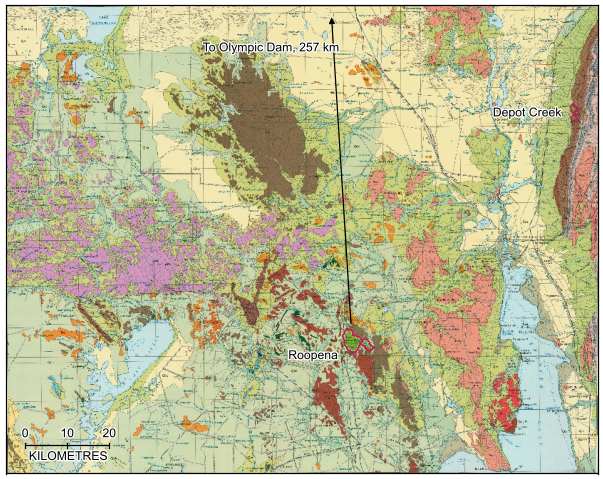

Roopena main patch centre 137.374 E -32.717; distance to Olympic Dam 257 km (great circle)
sheet area between the neat lines: 15,642 km2


In [8]:
step = 4
sheet = PA[PA_T:PA_B:step, PA_L:PA_R:step]
msh = np.isin(lab, pcr.label.values)[PA_T:PA_B:step, PA_L:PA_R:step]
fig, ax = plt.subplots(figsize=(COL15, COL15 * (1.0 / (1.5 * np.cos(np.radians(32.5)))) + 0.05))
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
ax.imshow(sheet, extent=(136.5, 138.0, -33.0, -32.0), interpolation="antialiased")
ax.contour(np.linspace(136.5, 138.0, msh.shape[1]), np.linspace(-32.0, -33.0, msh.shape[0]),
           ndimage.binary_dilation(msh, iterations=3).astype(float), levels=[0.5], colors="#c2185b", linewidths=1.0)
ax.set_aspect(1 / np.cos(np.radians(32.5)))
rr = pcr[pcr.field == "Roopena"].iloc[0]; dc = pcr[pcr.field != "Roopena"]
ax.text(rr.lon - 0.03, rr.lat - 0.02, "Roopena", ha="right", va="top", path_effects=HALO)
ax.text(dc.lon.mean() - 0.03, dc.lat.mean(), "Depot Creek", ha="right", va="center", path_effects=HALO)
d_od = haversine_km(rr.lon, rr.lat, OD_LON, OD_LAT)
ax.annotate("", xy=(rr.lon - 0.05, -32.02), xytext=(rr.lon, rr.lat + 0.03), arrowprops=dict(arrowstyle="-|>", color="black", lw=0.8))
ax.text(rr.lon - 0.035, -32.08, f"To Olympic Dam, {d_od:.0f} km", ha="right", va="top", path_effects=HALO)
ax.set_xlim(136.5, 138.0); ax.set_ylim(-33.0, -32.0)
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
for s_ in ax.spines.values(): s_.set_linewidth(0.8)
kmdeg = 111.32 * np.cos(np.radians(32.5)); sx, sy = 136.55, -32.94
for k in (0, 10, 20):
    ax.plot([sx + k / kmdeg] * 2, [sy - 0.006, sy + 0.006], color="black", lw=0.8)
    ax.text(sx + k / kmdeg, sy + 0.012, str(k), ha="center", va="bottom", path_effects=HALO)
ax.plot([sx, sx + 20 / kmdeg], [sy, sy], color="black", lw=0.8)
ax.text(sx + 10 / kmdeg, sy - 0.012, "KILOMETRES", ha="center", va="top", path_effects=HALO)
fig.savefig(FIG / "wp4_L2_A2_port_augusta_pcr.png", dpi=300)
plt.show()
print(f"Roopena main patch centre {rr.lon:.3f} E {rr.lat:.3f}; distance to Olympic Dam {d_od:.0f} km (great circle)")
print(f"sheet area between the neat lines: {6371.0**2*np.radians(1.5)*abs(np.sin(np.radians(-32))-np.sin(np.radians(-33))):,.0f} km2")


### How to read this figure

This is the 1968 PORT AUGUSTA first edition as printed, 136.5 to 138 E and 32 to 33 S, with north up and a 20 km scale bar. The magenta outlines, drawn slightly thickened so they can be seen at this scale, are the patches of the Roopena Volcanics unit: the Roopena field west of the Lincoln Gap hills and two small patches at Depot Creek on the far eastern side, in the Flinders foothills, where the legend calls the volcanics an equivalent. The arrow points to Olympic Dam, 257 km to the north and off this sheet. The picture says two things about the analog. It is one object, small against the sheet (8.6 km² of Pcr on a sheet of about 15,600 km², sea included), so it cannot by itself give an intensity of objects per 10,000 km². And it sits on the Gawler Craton margin, where cover is thin, far from the deep-cover shelf the prior is about.


### Step A3. How thick the Roopena volcanics are in the pre-t0 holes

Thickness is the second object statistic the annex wants from Roopena (working range 50 to 300 m of stacked flows). Six holes drilled before t0 went through the volcanics and into what lies beneath: Roopena DDH 1 to 4 (SADM, 1967-68) and BHP RP 1 and 2 (1969). Their SA Geodata logs are drawn as columns. Those logs carry modern unit names, so the 1968 reading of the first two holes, from Risely's report, is marked beside them as the period value.


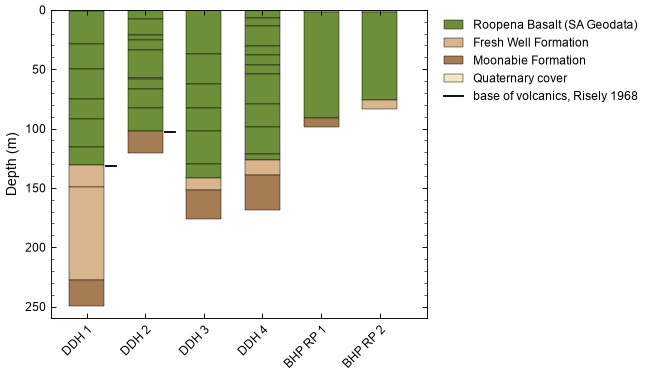

         hole    drilled  basalt_top_m  basalt_base_m  thickness_m  end_of_hole_m
ROOPENA DDH 1 1967-09-25           1.2          131.1        129.9          249.6
ROOPENA DDH 2 1967-10-16           0.0          101.8        101.8          120.5
ROOPENA DDH 3 1968-07-18           0.0          141.4        141.4          175.9
ROOPENA DDH 4 1968-08-20           0.0          126.3        126.3          168.3
     BHP RP 1 1969-12-12           1.8           91.4         89.6           99.1
     BHP RP 2 1969-12-12           1.5           76.2         74.7           83.8

volcanic thickness, 6 pre-t0 holes: 75 to 141 m (median 114 m); Risely 1968: DDH 1 base 431 ft = 131 m, DDH 2 base beyond 337 ft = 103 m
(not drawn) Pacminex EX holes 1973-74: 14 holes log Backy Point Formation, the sandstone under the volcanics, 3 to 32 m; none logs basalt


In [9]:
UNIT_COL = {"basalt": "#6d8f3a", "Fresh Well Formation": "#d9b58e", "Moonabie Formation": "#a67c52", "cover": "#f2e6c8", "other": "0.8"}
def ucat(u):
    u = str(u)
    if u.startswith("Roopena Basalt"): return "basalt"
    if u.startswith("Fresh Well"): return "Fresh Well Formation"
    if u.startswith("Moonabie"): return "Moonabie Formation"
    if u.startswith("Quaternary"): return "cover"
    return "other"
order = ["ROOPENA DDH 1", "ROOPENA DDH 2", "ROOPENA DDH 3", "ROOPENA DDH 4", "BHP RP 1", "BHP RP 2"]
fig, ax = plt.subplots(figsize=(COL15, 3.3))
fig.subplots_adjust(left=0.1, right=0.72, top=0.97, bottom=0.12)
thick = []
for k, hn in enumerate(order):
    iv = holes[holes.DH_NAME == hn].sort_values("DEPTH_FROM_M")
    for _, r in iv.iterrows():
        ax.add_patch(plt.Rectangle((k - 0.3, r.DEPTH_FROM_M), 0.6, r.DEPTH_TO_M - r.DEPTH_FROM_M,
                                   color=UNIT_COL[ucat(r.STRAT_UNIT_NAME)], ec="black", lw=0.3))
    b = iv[iv.STRAT_UNIT_NAME.str.startswith("Roopena Basalt")]
    thick.append(dict(hole=hn, drilled=iv.drill_date.iloc[0], basalt_top_m=b.DEPTH_FROM_M.min(), basalt_base_m=b.DEPTH_TO_M.max(),
                      thickness_m=b.DEPTH_TO_M.max() - b.DEPTH_FROM_M.min(), end_of_hole_m=iv.DEPTH_TO_M.max()))
r68 = rlog[rlog.unit_as_logged_1968 == "Roopena Volcanics"]
for hn, k in (("Roopena DDH 1", 0), ("Roopena DDH 2", 1)):
    base = r68.loc[r68.hole == hn, "to_m"].iloc[0]
    ax.plot([k + 0.33, k + 0.5], [base, base], color="black", lw=1.2)
ax.set_xlim(-0.6, len(order) - 0.2); ax.set_ylim(260, 0)
ax.set_xticks(range(len(order))); ax.set_xticklabels([o.replace("ROOPENA ", "") for o in order], rotation=45, ha="right", rotation_mode="anchor")
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylabel("Depth (m)")
h = [plt.Rectangle((0, 0), 1, 1, color=c, ec="black", lw=0.3, label=l) for l, c in
     [("Roopena Basalt (SA Geodata)", UNIT_COL["basalt"]), ("Fresh Well Formation", UNIT_COL["Fresh Well Formation"]),
      ("Moonabie Formation", UNIT_COL["Moonabie Formation"]), ("Quaternary cover", UNIT_COL["cover"])]]
h.append(plt.Line2D([], [], color="black", lw=1.2, label="base of volcanics, Risely 1968"))
ax.legend(handles=h, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(FIG / "wp4_L2_A3_volcanic_thickness.png", dpi=300)
plt.show()
th = pd.DataFrame(thick); print(th.round(1).to_string(index=False))
print(f"\nvolcanic thickness, 6 pre-t0 holes: {th.thickness_m.min():.0f} to {th.thickness_m.max():.0f} m (median {th.thickness_m.median():.0f} m); "
      f"Risely 1968: DDH 1 base 431 ft = {431*FT:.0f} m, DDH 2 base beyond 337 ft = {337*FT:.0f} m")
bpi = holes[holes.STRAT_UNIT_NAME == "Backy Point Formation"].groupby("DH_NAME").agg(top=("DEPTH_FROM_M", "min"), base=("DEPTH_TO_M", "max"))
bp = bpi.base - bpi.top
print(f"(not drawn) Pacminex EX holes 1973-74: {len(bp)} holes log Backy Point Formation, the sandstone under the volcanics, {bp.min():.0f} to {bp.max():.0f} m; none logs basalt")


### How to read this figure

Each column is one hole drilled before t0 at Roopena, from the surface (top) to the end of its log, with depth increasing downward. Green is the interval logged as Roopena Basalt in SA Geodata, tan the Fresh Well Formation beneath it, brown the Moonabie Formation, pale the thin Quaternary cover. The short black bars beside the first two columns are the base of the volcanics as Risely's 1968 report gives it: 131 m in DDH 1 and beyond 103 m in DDH 2. The modern logs match the period reading within a metre or two. Across the six holes the volcanic pile is 75 to 141 m thick (median 114 m), a single field seen at one place, not a distribution. That sits inside the annex's 50 to 300 m working range, in its lower half. The BHP RP 2 log calls its volcanic interval siltstone in the lithology column; that is an SA Geodata inconsistency, recorded rather than resolved here. The 14 Pacminex holes further north logged only the Backy Point sandstone under the volcanics, 3 to 32 m, and no basalt, so they bound the field's northern extent rather than thicken it.


### Step A4. What the Roopena volcanics weigh: Risely's specific gravities

Risely measured the specific gravity of surface samples along his traverses (report p. 11). These are the only era density values for the basalt object and they feed Level 5 as well; here they test the annex's working range for basalt density, 2.80 to 3.00 g/cc. Each sample is one dot, grouped by rock as Risely labelled it.


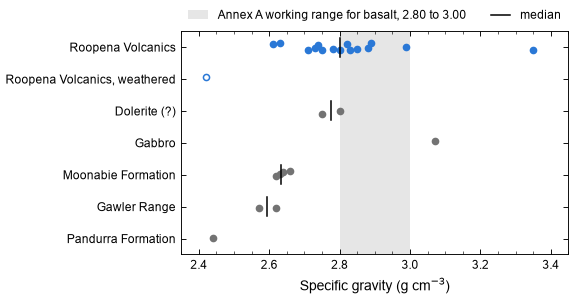

Roopena Volcanics, unweathered: n = 15, median 2.80, mean 2.824, range 2.61 to 3.35; inside 2.80-3.00: 7 of 15
Moonabie Formation (the rock beneath): median 2.635; contrast volcanics minus Moonabie: +0.17 g/cc
group means printed by Risely: [np.float64(2.6), np.float64(2.63), np.float64(2.645), np.float64(2.68), np.float64(2.82), np.float64(2.87)]


In [10]:
grp = {"Roopena Volcanic": "Roopena Volcanics", "Roopena Volcanic (weathered)": "Roopena Volcanics, weathered",
       "Dolerite (?)": "Dolerite (?)", "Moonabie Formation quartzite": "Moonabie Formation", "Pandurra Formation quartzite": "Pandurra Formation",
       "Gabbro": "Gabbro", "Gawler Range granophyre": "Gawler Range", "Gawler Range porphyry": "Gawler Range"}
sg["group"] = sg.rock.map(grp)
order = ["Roopena Volcanics", "Roopena Volcanics, weathered", "Dolerite (?)", "Gabbro", "Moonabie Formation", "Gawler Range", "Pandurra Formation"]
fig, ax = plt.subplots(figsize=(COL15, 2.9))
fig.subplots_adjust(left=0.33, right=0.97, top=0.86, bottom=0.16)
ax.axvspan(2.80, 3.00, color="0.9", lw=0, label="Annex A working range for basalt, 2.80 to 3.00")
rng = np.random.default_rng(0)
for k, gname in enumerate(order):
    v = sg.loc[sg.group == gname, "specific_gravity_gcc"]
    ax.plot(v, k + rng.uniform(-0.12, 0.12, len(v)), "o", ms=4, color=PIECE_COL[1] if gname.startswith("Roopena") else "0.45",
            mfc="white" if "weathered" in gname else None)
    if len(v) > 1: ax.plot([v.median()] * 2, [k - 0.3, k + 0.3], color="black", lw=1.0)
ax.plot([], [], color="black", lw=1.0, label="median")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(order) - 0.5, -0.5)
ax.set_xlabel("Specific gravity (g cm$^{-3}$)"); ax.set_xlim(2.35, 3.45)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.savefig(FIG / "wp4_L2_A4_risely_sg.png", dpi=300)
plt.show()
v = sg.loc[sg.group == "Roopena Volcanics", "specific_gravity_gcc"]
print(f"Roopena Volcanics, unweathered: n = {len(v)}, median {v.median():.2f}, mean {v.mean():.3f}, range {v.min():.2f} to {v.max():.2f}; "
      f"inside 2.80-3.00: {int(v.between(2.80, 3.00).sum())} of {len(v)}")
m = sg.loc[sg.group == "Moonabie Formation", "specific_gravity_gcc"]
print(f"Moonabie Formation (the rock beneath): median {m.median():.3f}; contrast volcanics minus Moonabie: {v.median() - m.median():+.2f} g/cc")
print("group means printed by Risely:", sorted(sg.group_mean_printed.dropna().unique()))


### How to read this figure

Each dot is one surface sample, placed at its measured specific gravity (horizontally) in the row of the rock Risely assigned it to; small vertical scatter only separates overlapping dots. Blue dots are the Roopena Volcanics (the open one is the weathered sample, 2.42), grey dots the neighbouring rocks, black ticks the medians, and the grey band the 2.80 to 3.00 g/cc range the annex carries for basalt. The 15 unweathered volcanic samples run from 2.61 to 3.35 with a median of 2.80; 7 of the 15 fall inside the annex band, and Risely's own group means are 2.68 for the northern samples and 2.82 to 2.87 for the southern. Against the Moonabie Formation beneath (median 2.64) the contrast is about +0.17 g/cc. Two cautions travel with these numbers. They are surface samples, some of them leached, so they are likely low for fresh flows at depth. And Risely found the volcanics sitting in a gravity trough, despite their higher density, which he attributed to the regional field: the density contrast is real, but at Roopena it did not make a simple gravity high.


### Verdict on basis piece 1: Roopena mapping

On disk: yes, all four records plus the pre-t0 drill logs, in `roopena_mapping/`. In state: yes by date (1952, 1968, 1 Nov 1968, July 1970); the 1970 BHP summary was released to open file only in November 1977, which matters if the ruling is an idealised open-file explorer. Contribution: the Roopena field gives one observed object with a mapped outcrop of 8.6 km² (4.7 by 3.6 km, long axis at 157°), a drilled thickness of 75 to 141 m, and surface densities with median 2.80 g/cc, a contrast of about +0.17 g/cc on the rock beneath. It does not give distributions (one field, one place) or an intensity, and one correction goes into the citation table: the mapping that shows the object is the 1968 PORT AUGUSTA sheet, not the 1952 Roopena sheet, whose legend has no volcanic unit.


## Part B, basis piece 2: the WMC targeting memoranda

The annex names Haynes's targeting memoranda as the source for the basalt-object intensity, the lineament multiplier and (in Level 4) the ore rule and its reach. No WMC memorandum dated before t0 is in open file: the SARIG catalogue and the WP1 acquisition index were searched, and the memoranda are internal WMC papers now in BHP's archive (the inventory's gap S22). This part shows the nearest admissible WMC text and the in-state period statement of part of the concept that turned up in piece 1. The 1974 WMC targeting plans that also survive are O'Driscoll sheets and are treated in Part C.

### Step B1. The nearest admissible WMC statement, and Risely's 1968 reading

The figure is the concept paragraph (section 1.2) of the EL 190 first quarterly as a page crop. It is the earliest WMC statement of the concept on disk, written a quarter after t0 and admitted only for what it says of the position at grant. The cell prints the passage of Risely's 1968 conclusions that places copper at the base of the Roopena volcanics.


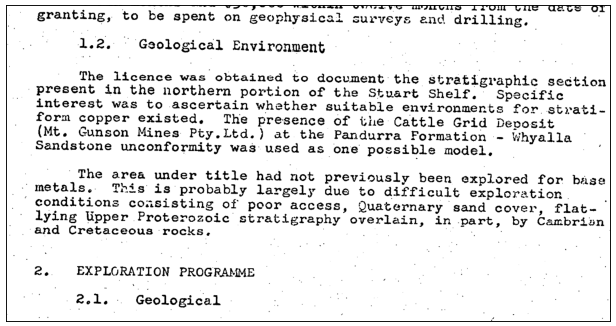

Risely 1968, RB 67/00081, conclusions (report p. 19, PDF p. 23), text layer as extracted:
  ...A third control might have been the unconformity between the Roopena Volcanics and the Corunna Conglomerate putting the suitable environment immediately beneath the volcanics.      This control appears necessary to explain the fact that no copper minerals have been found over the inferred anticline and syncline in the siltstones of the Corunna Conglomerate outcropping at thesouth of the so-called favourable area.    It is not known if mineralization was associated with this un>- conformity as it has not been found ...

found in piece 2 folder: ['NOT_FOUND.md', 'finding_aid_not_admissible', 'nearest_admissible_EL190_Q1']


In [11]:
im = Image.open(WM / "nearest_admissible_EL190_Q1/m90_p007_geological_environment.png").convert("RGB")
w, h = im.size
fig, ax = plt.subplots(figsize=(COL15, COL15 * h / w))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.imshow(np.asarray(im)); ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
for s_ in ax.spines.values(): s_.set_linewidth(0.6)
fig.savefig(FIG / "wp4_L2_B1_el190_statement.png", dpi=300)
plt.show()
start = next(i for i, l in enumerate(rtext) if "CONCLUSIONS AND RECOMMENDATIONS" in l and i > 1000)
body = [l.strip() for l in rtext[start:start + 60] if l.strip()]
txt = " ".join(body)
k = txt.find("A third control")
print("Risely 1968, RB 67/00081, conclusions (report p. 19, PDF p. 23), text layer as extracted:")
print("  ..." + txt[k:k + 520] + "...")
print("\nfound in piece 2 folder:", sorted(p.name for p in WM.iterdir()))


### How to read this figure

The image is section 1.2, "Geological environment", of WMC's first quarterly report on EL 190 (open-file envelope 2583, mesac24890, p. 7), photographed from the scan. It says WMC set out "to ascertain whether suitable environments for stratiform copper existed" and used the Cattle Grid deposit of Mount Gunson, at the Pandurra Formation to Whyalla Sandstone unconformity, "as one possible model". It names no basalt source, no fault conduit and no lineament; it is the stratiform-copper concept of the period, not the basalt-donor concept the annex encodes. The printed passage below the figure is from Risely's 1968 Roopena report, a SADM document from before t0: it proposes as a control the unconformity "between the Roopena Volcanics and the Corunna Conglomerate putting the suitable environment immediately beneath the volcanics". That is the nearest in-state written statement of the annex's rule that copper sits at the contact beside or beneath a basalt pile, and it was written about Roopena, not the Stuart Shelf.


### Verdict on basis piece 2: the WMC targeting memoranda

On disk: no; not in any public archive. In state: nothing written by WMC before t0 survives in open file. Contribution: none directly. Stand-ins, labelled in the folder: the EL 190 first quarterly (QUALIFIED, and it states the stratiform Cattle Grid concept, not basalt-donor); Risely 1968, which puts copper immediately beneath the Roopena volcanics; Haynes 2006 as a finding aid only; and, found in Part C, two 1974 WMC targeting plans (OD6 iv, blue targets; OD7 i) that record where WMC targeted, though not the rule in words. The decision for you and your advisor stands: request the memoranda from BHP's archive, or cite the Level 2 intensity and multiplier to O'Driscoll's 1974 sheets and the ore rule to Risely 1968 plus EL 190, with the basalt-donor reading carried as testimony.


## Part C, basis piece 3: O'Driscoll's interpretation

The GA package holds 130 scans of WMC's original lineament and target sheets; 34 are on the Andamooka, Torrens and Stuart Shelf window. The GA index gives content flags but no dates, so each sheet was dated from its own face: side and top label tabs, title blocks, legends and pencil notes, zooming where needed. The transcription is `odriscoll_window_sheet_dates.csv`.

### Step C1. Which of the 34 window sheets are in state


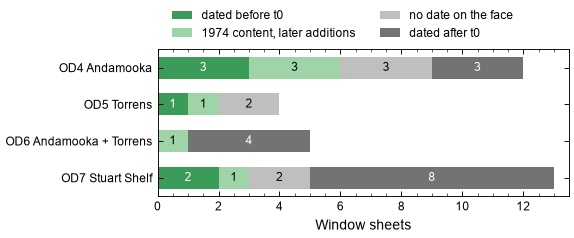


IN:
    sheet date_on_face                                                             title_as_read
   OD4_iv         1974             Andamooka photo-lineaments and structural targets, E.S.T.O'D.
   OD4_ix         1971           Andamooka Bouguer gravity anomalies, 2 mgl contours (71-413 BC)
OD4_xxxii         1974 Andamooka photolineaments and tectonic targets (ERTS lineaments in black)
  OD5_iii         1974                                          Torrens lins. + tectonic targets
    OD7_i    Sept 1974      Stuart Shelf exploration plan 2616-01, Andamooka area (xerox splice)
    OD7_v         1974            Stuart Shelf photolineaments E.S.T.O'D., by T. O'Driscoll 1974

PARTLY:
    sheet                                                   date_on_face                                                                                                                                       title_as_read
  OD4_vii                                             1974 / 1980 / 1984              

In [12]:
dates["project"] = dates.sheet.str.extract(r"^(OD\d)")[0]
PROJ = {"OD4": "OD4 Andamooka", "OD5": "OD5 Torrens", "OD6": "OD6 Andamooka + Torrens", "OD7": "OD7 Stuart Shelf"}
ST = [("in", "dated before t0", PIECE_COL[3]), ("partly", "1974 content, later additions", "#9fd3a8"),
      ("undated", "no date on the face", "0.75"), ("out", "dated after t0", "0.45")]
tab = dates.groupby(["project", "status_t0"]).size().unstack(fill_value=0).reindex(columns=[s[0] for s in ST], fill_value=0)
fig, ax = plt.subplots(figsize=(COL15, 2.3))
fig.subplots_adjust(left=0.3, right=0.98, top=0.78, bottom=0.2)
left = np.zeros(len(tab))
for key, lab_, c in ST:
    ax.barh(range(len(tab)), tab[key], left=left, color=c, height=0.6, label=lab_, lw=0)
    for i, (l_, v) in enumerate(zip(left, tab[key])):
        if v: ax.text(l_ + v / 2, i, str(v), ha="center", va="center", color="white" if key in ("in", "out") else "black")
    left += tab[key].values
ax.set_yticks(range(len(tab))); ax.set_yticklabels([PROJ[p] for p in tab.index]); ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_ylim(len(tab) - 0.5, -0.5); ax.set_xlabel("Window sheets"); ax.set_xlim(0, tab.sum(axis=1).max() + 0.5)
ax.legend(loc="lower center", bbox_to_anchor=(0.45, 1.0), ncol=2)
fig.savefig(FIG / "wp4_L2_C1_sheet_dates.png", dpi=300)
plt.show()
pd.set_option("display.max_colwidth", 80)
for st in ("in", "partly"):
    print(f"\n{st.upper()}:")
    print(dates.loc[dates.status_t0 == st, ["sheet", "date_on_face", "title_as_read"]].to_string(index=False))
print("\ncounts:", dates.status_t0.value_counts().to_dict())


### How to read this figure

Each bar is one of O'Driscoll's four project series on the window, and its segments count the sheets by what their faces say about date: dark green dated before t0, pale green carrying 1974 content under later additions, light grey with no date at all, dark grey dated after t0. Of the 34 window sheets, 6 are in state: OD4 ix (the 1971 SADM Bouguer map WMC worked on), OD4 iv, OD4 xxxii, OD5 iii and OD7 v (1974 photo-lineaments and targets), and OD7 i (a Sept 1974 exploration plan with a WMC proposed drill hole). Six more carry 1974 content under later work; the most important is OD6 iv, the plan for WMC's 30 September to 5 October 1974 target-selection meeting, whose blue "T.O'D targets (1974)" are in state while its red "D.McP.D targets (1976)" and its tenement notes of 1974-75 are not. Fifteen sheets are dated after t0 (1976 to 1984, several of them Seltrust or 1983 period-report plans) and 7 carry no date. What the reader should take away: O'Driscoll's in-state interpretation exists, is dated 1974 on its own faces, and can be separated sheet by sheet from the later redrawings that know the outcome.


### Step C2. OD4 iv, the 1974 photo-lineament and target sheet, around the deposit

OD4 iv is the sheet O'Driscoll signed and dated 1974 for the Andamooka sheet area. A 40 by 30 km crop around the deposit is placed through GA's world file, in AGD66 / AMG zone 53 coordinates, with the deposit marked. This is what the lineament piece looks like where the prior matters most.


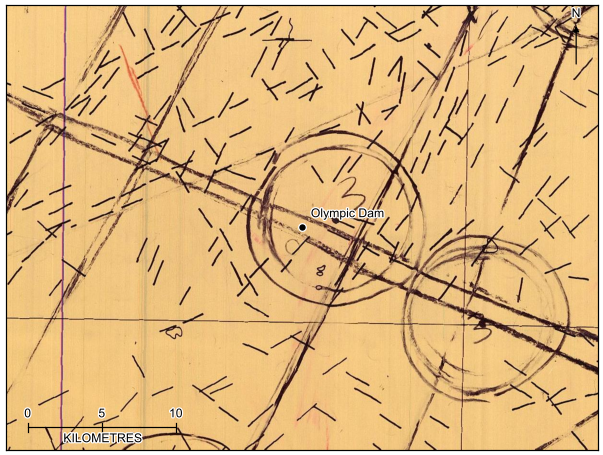

OD4 iv: 5798 x 4651 px at 32.3 m/px; deposit at sheet pixel (1990, 1811); crop 1237 x 928 px


In [13]:
def read_jgw(p):
    a, _, _, e, x0, y0 = [float(v) for v in Path(p).read_text().split()]
    return a, e, x0, y0
WS = ODI / "window_sheets"
a, e, x0, y0 = read_jgw(WS / "OD4_iv_agd66_amg_Z53.jgw")
im = Image.open(WS / "OD4_iv_agd66_amg_Z53.jpg").convert("RGB")
HW, HH = 20.0, 15.0
px, py = (OD_E66 - x0) / a, (OD_N66 - y0) / e
crop = im.crop((int(px - HW * 1000 / a), int(py - HH * 1000 / abs(e)), int(px + HW * 1000 / a), int(py + HH * 1000 / abs(e))))
fig, ax = plt.subplots(figsize=(COL15, COL15 * HH / HW + 0.05))
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
ax.imshow(np.asarray(crop), extent=(-HW, HW, -HH, HH), interpolation="antialiased")
ax.plot(0, 0, "o", color="black", ms=5, mec="white", mew=0.8)
ax.text(0.6, 0.5, "Olympic Dam", va="bottom", path_effects=HALO)
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
for s_ in ax.spines.values(): s_.set_linewidth(0.8)
for k in (0, 5, 10):
    ax.plot([-HW + 1.5 + k] * 2, [-HH + 1.2, -HH + 1.8], color="black", lw=0.8)
    ax.text(-HW + 1.5 + k, -HH + 2.0, str(k), ha="center", va="bottom", path_effects=HALO)
ax.plot([-HW + 1.5, -HW + 11.5], [-HH + 1.5, -HH + 1.5], color="black", lw=0.8)
ax.text(-HW + 6.5, -HH + 1.1, "KILOMETRES", ha="center", va="top", path_effects=HALO)
ax.annotate("", xy=(HW - 1.5, HH - 1.2), xytext=(HW - 1.5, HH - 4.2), arrowprops=dict(arrowstyle="-|>", color="black", lw=0.8))
ax.text(HW - 1.5, HH - 1.0, "N", ha="center", va="bottom", path_effects=HALO)
fig.savefig(FIG / "wp4_L2_C2_od4iv_deposit.png", dpi=300)
plt.show()
print(f"OD4 iv: {im.size[0]} x {im.size[1]} px at {a:.1f} m/px; deposit at sheet pixel ({px:.0f}, {py:.0f}); crop {crop.size[0]} x {crop.size[1]} px")


### How to read this figure

The crop is the 1974 OD4 iv sheet as O'Driscoll drew it, 40 km wide and 30 km high around Olympic Dam (black dot), placed by the world file GA supplied with the scan; north up is AMG grid north, about 1° from true north here (grid convergence at 136.9 E), and the scale bar is 10 km. The short black strokes are his photo-lineaments, the longer ruled lines the lineament trends he drew through them, and the circles his structural targets. What the reader should see is that the deposit sits inside the double-ringed circle O'Driscoll numbered 3, on the southern of two parallel WNW-trending lineaments, with a NNE trend crossing them about 3 km to the east-southeast rather than at the deposit itself; this is the reading of the sheet already recorded in the WP4 notes. The sheet gives the geometry of O'Driscoll's structural reasoning at t0; it does not give a written rule or a number.


### Step C3. What the 1974 targeting implies for the lineament multiplier

The annex's lineament multiplier (working range 2 to 5) is an intensity ratio, and the maps give no written number for it. What they can give without digitising every lineament is how strongly the 1974 targeting concentrated attention. On OD6 iv, the plan for WMC's September 1974 target-selection meeting, O'Driscoll's own 1974 targets are the blue circles. They were transcribed by matching ring-shaped blue ink (16 circles) and placing 4 that the matcher missed by eye (`odriscoll_OD6iv_1974_blue_targets.csv`). The cell measures the area of their union and compares it with the two sheets' area. If all the concept's expected objects were believed to lie inside the targets, the intensity inside them would be 1/f times the sheet average, where f is the covered fraction. That ratio is therefore an upper bound on what the maps could justify as a multiplier.


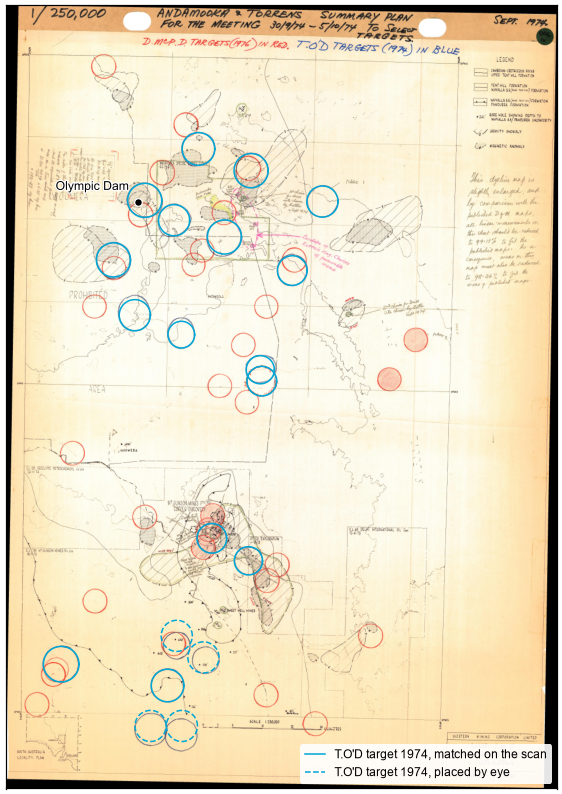

1974 T.O'D targets on OD6 iv: 20 circles (16 matched, 4 by eye), radius median 5.25 km (range 4.50 to 6.00)
union of the circles: 1,728 km2; ANDAMOOKA + TORRENS (30-32 S, 136.5-138 E): 31,793 km2; covered fraction f = 0.054
implied concentration if all expected objects lay inside the targets, 1/f = 18
nearest target to the deposit: TOD74-14, centre 2.5 km away, radius 5.75 km -> deposit inside: True


In [14]:
a6, e6, x06, y06 = read_jgw(WS / "OD6_iv_agd66_amg_Z53.jgw")
im6 = Image.open(WS / "OD6_iv_agd66_amg_Z53.jpg").convert("RGB")
W6, H6 = im6.size; st6 = 6
ext6 = (x06 / 1000, (x06 + W6 * a6) / 1000, (y06 + H6 * e6) / 1000, y06 / 1000)
g = 0.25   # km grid for the union area
xs = np.arange((tgt.easting_amg66 - tgt.radius_km * 1000).min(), (tgt.easting_amg66 + tgt.radius_km * 1000).max(), g * 1000)
ys = np.arange((tgt.northing_amg66 - tgt.radius_km * 1000).min(), (tgt.northing_amg66 + tgt.radius_km * 1000).max(), g * 1000)
XX, YY = np.meshgrid(xs, ys); inside = np.zeros(XX.shape, bool)
for _, r in tgt.iterrows():
    inside |= np.hypot(XX - r.easting_amg66, YY - r.northing_amg66) <= r.radius_km * 1000
union_km2 = inside.sum() * g * g
R = 6371.0
sheets_km2 = R ** 2 * np.radians(1.5) * abs(np.sin(np.radians(-30.0)) - np.sin(np.radians(-32.0)))
f = union_km2 / sheets_km2
tgt["dist_od_km"] = np.hypot(tgt.easting_amg66 - OD_E66, tgt.northing_amg66 - OD_N66) / 1000
hit = tgt.sort_values("dist_od_km").iloc[0]

fig, ax = plt.subplots(figsize=(COL15, COL15 * (ext6[3] - ext6[2]) / (ext6[1] - ext6[0]) * 0.93))
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
ax.imshow(np.asarray(im6.reduce(st6)), extent=ext6, interpolation="antialiased")
ang = np.linspace(0, 2 * np.pi, 120)
for _, r in tgt.iterrows():
    ax.plot(r.easting_amg66 / 1000 + r.radius_km * np.cos(ang), r.northing_amg66 / 1000 + r.radius_km * np.sin(ang),
            color="#00a6d6", lw=1.0, ls="-" if r.method.startswith("auto") else "--")
ax.plot(OD_E66 / 1000, OD_N66 / 1000, "o", color="black", ms=5, mec="white", mew=0.8, zorder=5)
ax.text(OD_E66 / 1000 - 3, OD_N66 / 1000 + 4, "Olympic Dam", ha="right", path_effects=HALO)
ax.set_xlim(ext6[0], ext6[1]); ax.set_ylim(ext6[2], ext6[3]); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(length=0)
for s_ in ax.spines.values(): s_.set_linewidth(0.8)
h = [plt.Line2D([], [], color="#00a6d6", lw=1.0, label="T.O'D target 1974, matched on the scan"),
     plt.Line2D([], [], color="#00a6d6", lw=1.0, ls="--", label="T.O'D target 1974, placed by eye")]
ax.legend(handles=h, loc="lower right", framealpha=0.9, frameon=True, edgecolor="none")
fig.savefig(FIG / "wp4_L2_C3_od6iv_1974_targets.png", dpi=300)
plt.show()
print(f"1974 T.O'D targets on OD6 iv: {len(tgt)} circles ({(tgt.method.str.startswith('auto')).sum()} matched, {(~tgt.method.str.startswith('auto')).sum()} by eye), "
      f"radius median {tgt.radius_km.median():.2f} km (range {tgt.radius_km.min():.2f} to {tgt.radius_km.max():.2f})")
print(f"union of the circles: {union_km2:,.0f} km2; ANDAMOOKA + TORRENS (30-32 S, 136.5-138 E): {sheets_km2:,.0f} km2; covered fraction f = {f:.3f}")
print(f"implied concentration if all expected objects lay inside the targets, 1/f = {1/f:.0f}")
print(f"nearest target to the deposit: {hit.target}, centre {hit.dist_od_km:.1f} km away, radius {hit.radius_km:.2f} km -> deposit inside: {hit.dist_od_km < hit.radius_km}")


### How to read this figure

The picture is OD6 iv, WMC's September 1974 summary plan of the ANDAMOOKA and TORRENS sheets for the target-selection meeting, placed in AMG coordinates by GA's world file. The cyan rings are the transcribed blue "T.O'D targets (1974)": solid where the ring was matched on the scan, dashed where it was placed by eye. The red circles printed on the sheet are D.McP.D's 1976 targets and are not counted. The black dot is Olympic Dam. The 20 circles have a median radius of 5.25 km, and their union covers 1,728 km² of the two sheets' 31,793 km², a fraction f of 0.054. If the concept expected all of its objects inside these targets, the intensity inside them would be about 18 times the average. That is an upper bound on a lineament multiplier the 1974 maps could justify, and the annex's 2 to 5 is well inside it; the maps cannot narrow the multiplier further without the lineaments digitised and a rule for which ones count. The deposit falls inside target TOD74-14, 2.5 km from its centre, on the coincident magnetic and gravity anomaly west of the Andamooka stones field. That is a statement about where WMC looked in 1974, not a parameter, and it must not be used to tune the prior, under the double-use rule.


### Verdict on basis piece 3: O'Driscoll's interpretation

On disk: yes, all 34 window sheets with world files, the GA index and metadata, in `odriscoll_interpretation/`. In state: 6 sheets dated before t0 on their faces, 6 more with 1974 content under later additions; 15 are after t0 and 7 undated. Contribution: the geometry of the 1974 structural targeting, including OD4 iv at the deposit and the 20 blue 1974 targets of OD6 iv, whose union covers 5.4% of the two sheets and so bounds any map-based multiplier at about 18. What it does not contribute: a written report (the package is maps only), a numerical multiplier, or the elongation-along-structure rule in words. Two items for the citation table: the multiplier row can cite OD6 iv and OD4 iv with a translation note ("1974 targets at lineament intersections; multiplier bounded above by 1/f = 18"); and O'Driscoll's own lineament-control statistic, 9 of 12 occurrences within 2.5 miles of a WNW lineament, is on OD6 v and vi, dated 1983, and must stay out.


## Part D: the three pieces against the Annex A Level 2 rows

### Step D1. What each Level 2 parameter can now cite

Four of the annex's Level 2 parameter rows can now be set against in-state values from the pieces above. The fifth, the basalt-object intensity (count per 10,000 km²), cannot: Roopena is one field, and counting anomalies on the t0 maps is forbidden. Each panel shows the annex's working range as a grey band and the in-state evidence as marks, in its own units. Density belongs to Level 5 but comes from Risely, so it is shown here.


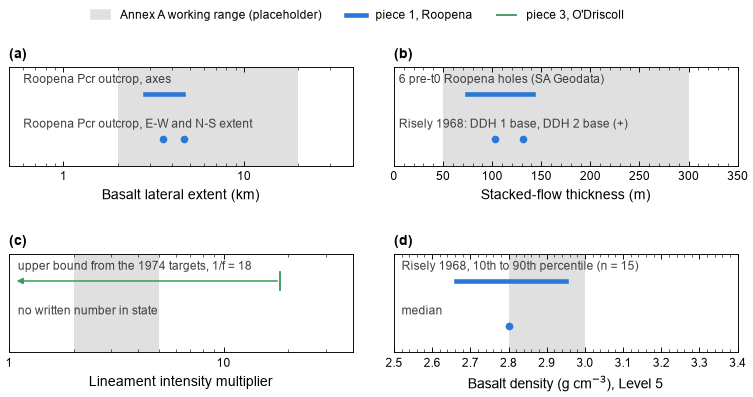

(a) extent: Roopena outcrop 3.6 x 4.7 km (axes 4.6/2.8) vs annex 2-20 km
(b) thickness: 75-141 m vs annex 50-300 m
(c) multiplier: annex 2-5; upper bound from the 1974 targets 1/f = 18
(d) density: Risely median 2.80, 10-90% 2.66-2.95 vs annex 2.80-3.00
intensity (count per 10,000 km2): not citable from these pieces


In [15]:
v = sg.loc[sg.group == "Roopena Volcanics", "specific_gravity_gcc"]
fig, axs = plt.subplots(2, 2, figsize=(COL2, 3.6))
fig.subplots_adjust(left=0.06, right=0.98, top=0.84, bottom=0.12, hspace=0.9, wspace=0.12)
def panel(ax, band, xlab, xlim, log=False):
    ax.axvspan(*band, color="0.88", lw=0)
    ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(-0.6, 1.6)
    ax.set_xlabel(xlab); ax.set_xlim(*xlim)
    if log: ax.set_xscale("log"); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:g}"))
a0, a1, a2, a3 = axs.ravel()
panel(a0, (2, 20), "Basalt lateral extent (km)", (0.5, 40), log=True)
a0.plot([rr.short_axis_km, rr.long_axis_km], [1, 1], color=PIECE_COL[1], lw=3)
a0.plot([pcr[pcr.field == "Roopena"].iloc[0].ew_km, pcr[pcr.field == "Roopena"].iloc[0].ns_km], [0, 0], "o", color=PIECE_COL[1], ms=4)
a0.text(0.6, 1.25, "Roopena Pcr outcrop, axes", color="0.25"); a0.text(0.6, 0.25, "Roopena Pcr outcrop, E-W and N-S extent", color="0.25")
panel(a1, (50, 300), "Stacked-flow thickness (m)", (0, 350))
a1.plot([th.thickness_m.min(), th.thickness_m.max()], [1, 1], color=PIECE_COL[1], lw=3)
a1.plot([431 * FT, 337 * FT], [0, 0], "o", color=PIECE_COL[1], ms=4)
a1.text(5, 1.25, "6 pre-t0 Roopena holes (SA Geodata)", color="0.25"); a1.text(5, 0.25, "Risely 1968: DDH 1 base, DDH 2 base (+)", color="0.25")
panel(a2, (2, 5), "Lineament intensity multiplier", (1, 40), log=True)
a2.annotate("", xy=(1.05, 1), xytext=(1 / f, 1), arrowprops=dict(arrowstyle="-|>", color=PIECE_COL[3], lw=1.0))
a2.plot([1 / f] * 2, [0.8, 1.2], color=PIECE_COL[3], lw=1.2)
a2.text(1.1, 1.25, f"upper bound from the 1974 targets, 1/f = {1/f:.0f}", color="0.25")
a2.text(1.1, 0.25, "no written number in state", color="0.25")
panel(a3, (2.80, 3.00), "Basalt density (g cm$^{-3}$), Level 5", (2.5, 3.4))
a3.plot([v.quantile(0.1), v.quantile(0.9)], [1, 1], color=PIECE_COL[1], lw=3)
a3.plot(v.median(), 0, "o", color=PIECE_COL[1], ms=4)
a3.text(2.52, 1.25, "Risely 1968, 10th to 90th percentile (n = 15)", color="0.25"); a3.text(2.52, 0.25, "median", color="0.25")
panel_labels((a0, a1, a2, a3), ("(a)", "(b)", "(c)", "(d)"))
h = [plt.Rectangle((0, 0), 1, 1, color="0.88", label="Annex A working range (placeholder)"),
     plt.Line2D([], [], color=PIECE_COL[1], lw=3, label="piece 1, Roopena"), plt.Line2D([], [], color=PIECE_COL[3], lw=1.2, label="piece 3, O'Driscoll")]
fig.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=3)
fig.savefig(FIG / "wp4_L2_D1_parameters.png", dpi=300)
plt.show()
print(f"(a) extent: Roopena outcrop {rr.ew_km:.1f} x {rr.ns_km:.1f} km (axes {rr.long_axis_km:.1f}/{rr.short_axis_km:.1f}) vs annex 2-20 km")
print(f"(b) thickness: {th.thickness_m.min():.0f}-{th.thickness_m.max():.0f} m vs annex 50-300 m")
print(f"(c) multiplier: annex 2-5; upper bound from the 1974 targets 1/f = {1/f:.0f}")
print(f"(d) density: Risely median {v.median():.2f}, 10-90% {v.quantile(0.1):.2f}-{v.quantile(0.9):.2f} vs annex 2.80-3.00")
print("intensity (count per 10,000 km2): not citable from these pieces")


### How to read this figure

Each panel is one Annex A Level 2 parameter; the grey band is the annex's placeholder working range, and the marks are what an in-state source now supports. In (a), lateral extent on a log axis, the Roopena outcrop is 3.6 by 4.7 km (dots) with principal axes of 2.8 and 4.6 km (bar), at the small end of the 2 to 20 km band: one object, mapped at outcrop, where erosion and alluvium may hide its true size. In (b) the six pre-t0 Roopena holes give 75 to 141 m of stacked flows (bar) and Risely's 1968 bases 131 and beyond 103 m (dots), all in the lower half of the 50 to 300 m band. In (c) no number exists in state; the arrow runs from the upper bound the 1974 targets imply (about 18) down toward 1, and the annex's 2 to 5 sits inside it. In (d), density on the Level 5 row, Risely's samples have a median of 2.80 and a 10th to 90th percentile range of 2.66 to 2.95, overlapping the annex band but reaching below it. Read together, the band values for extent and thickness are defensible from a single analog, the multiplier is bounded but not measured, and the density band should be widened downward or carried with Risely's spread.


## Verdict on Level 2

Two of the three basis pieces are on disk and in state; the third, the WMC targeting memoranda, is not in any public archive. The Roopena mapping supplies one observed basalt object: 8.6 km² at outcrop on the 1968 PORT AUGUSTA sheet (4.7 by 3.6 km, long axis 157°), 75 to 141 m thick in six pre-t0 holes, surface density median 2.80 g/cc, and the 1952 Roopena sheet named by the annex does not show it at all. O'Driscoll's interpretation supplies dated 1974 geometry: 6 sheets in state and 6 with 1974 content, OD4 iv placing the deposit in a structural target at a lineament crossing, and the 20 blue 1974 targets of WMC's September 1974 selection plan covering 5.4% of the two sheets. That bounds a map-based multiplier above at about 18 and leaves the annex's 2 to 5 as a translation to be recorded. The written targeting rule, the basalt-object intensity and the elongation along structure are not supported by any in-state document on disk; the nearest in-state statement of the ore-at-basalt-contact idea is Risely's 1968 Roopena report, and the only WMC text before or near t0 describes stratiform Cattle Grid copper.

For the citation table: extent and thickness rows cite Roopena (PORT AUGUSTA 1968, Risely 1968, the SADM and BHP logs) as a single analog with wide translation ranges; the multiplier row cites OD4 iv and OD6 iv with the 1/f bound as the translation note; the intensity row stays "to elicit", from geological reasoning only; and the memoranda decision, request from BHP or carry as testimony, is yours and your advisor's. Also for the rulings list: Jones 1970 went to open file only in November 1977, and O'Driscoll's 1983 lineament-control statistic must stay out.
